In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

warnings.filterwarnings('ignore', category=RuntimeWarning)
print('Imports OK')

Imports OK


In [5]:
# ── Cell 2: Paths + subjects ──────────────────────────────────────────────────
_BASE = (
    '/Users/farjam/Library/CloudStorage'
    '/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP'
)
ECOC_ROOT  = Path(_BASE) / 'ECOC'
PLOTS_ROOT = Path(_BASE) / 'Plots'
MDS_ROOT = Path(_BASE) / 'MDS'


AGE_DATA = {
    '1001': 25.0, '1002': 43.0, '1004': 33.0, '1005': 50.0, '1007': 31.0,
    '1008': 25.0, '1010': 26.0, '1011': 37.0, '1014': 23.0, '1016': 36.0,
    '1017': 46.0, '1018': 25.0, '1020': 29.0, '1021': 28.0, '1023': 46.0,
    '1024': 24.0, '1026': 25.0, '1028': 62.0, '1034': 60.0, '1038': 45.0,
    '1039': 63.0, '1041': 49.0, '1042': 39.0, '1044': 62.0, '1046': 61.0,
    '1052': 53.0, '2002': 62.0, '2006': 25.0, '2009': 49.0, '2017': 31.0,
    '2020': 43.0, '2023': 49.0, '2026': 47.0, '2028': 29.0, '2029': 50.0,
    '2037': 45.0, '3001': 54.0, '3005': 39.0, '3006': 33.0, '3007': 41.0,
    '3008': 32.0, '3011': 31.0, '3014': 34.0, '3016': 44.0, '3027': 72.0,
    '3030': 54.0, '3034': 48.0, '3039': 34.0, '3041': 35.0,
}
SUBJECTS = list(AGE_DATA.keys())

PATHWAYS = {
    'Luminance': {
        'contrasts': np.array([0.035, 0.07,  0.14,  0.28],  float),
        'color':     '#555555',
    },
    'L-M': {
        'contrasts': np.array([0.008, 0.016, 0.032, 0.064], float),
        'color':     '#b23333',
    },
    'S-cone': {
        'contrasts': np.array([0.06,  0.12,  0.24,  0.48],  float),
        'color':     '#3333cc',
    },
}

TIME_RANGE = [0.05, 0.30]   # seconds — analysis window

# MDS quality thresholds
QC_RHO   = 0.70   # min corr(MDS projection, contrast)
QC_DCORR = 0.90   # min MDS distance faithfulness
QC_RANGE = 0.20   # min dynamic range as fraction of subject's max

print(f'Subjects : {len(SUBJECTS)}')

Subjects : 49


In [15]:
# ── Cell 3: Pathway choice ────────────────────────────────────────────────────
# Change PATHWAY here, then re-run this cell before running Cells 5 and 6.

PATHWAY = 'S-cone'   # ← 'Luminance', 'L-M', or 'S-cone'

ecoc_dir  = ECOC_ROOT  / PATHWAY
plots_dir = PLOTS_ROOT / PATHWAY
plots_dir.mkdir(parents=True, exist_ok=True)
mds_dir = MDS_ROOT / PATHWAY
mds_dir.mkdir(parents=True, exist_ok=True)

contrasts = PATHWAYS[PATHWAY]['contrasts']
color     = PATHWAYS[PATHWAY]['color']
n_levels  = len(contrasts)

print(f'Pathway : {PATHWAY}')
print(f'ECOC    : {ecoc_dir}')
print(f'Plots   : {plots_dir}')
print(f'MDS     : {mds_dir}')

Pathway : S-cone
ECOC    : /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/ECOC/S-cone
Plots   : /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/S-cone
MDS     : /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/MDS/S-cone


In [16]:
# ── Cell 4: Helper functions ──────────────────────────────────────────────────

def cm_to_rdm(cm):
    """
    Row-normalised confusion matrix → d-prime RDM.
    Confusion (similarity) is symmetrised then converted to d-prime distance.
    """
    cm  = cm / (cm.sum(axis=1, keepdims=True) + 1e-9)
    S   = 0.5 * (cm + cm.T)        # symmetric similarity
    A   = 1.0 - S                   # accuracy-like matrix
    np.fill_diagonal(A, 0.5)
    A   = 0.5 * (A + A.T)
    np.fill_diagonal(A, 0.5)
    eps = 1e-6
    p   = np.clip(A, 0.5 + eps, 1 - eps)
    D   = np.sqrt(2) * norm.ppf(p)  # d-prime
    D  -= D.min()
    D   = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)
    return D


def cmdscale_1d(D):
    """
    Classical 1-D MDS.
    Projects the 4 contrast levels onto a single axis that best preserves
    their pairwise distances in the RDM.
    """
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n      # centring matrix
    B = -0.5 * J @ (D ** 2) @ J              # double-centred squared distances
    vals, vecs = np.linalg.eigh(B)
    return vecs[:, -1] * np.sqrt(max(vals[-1], 0.0))   # largest eigenvector


def align_scale(x, contrasts):
    """
    Flip sign so the MDS axis correlates positively with contrast,
    then scale to [0, 1].
    """
    if np.corrcoef(x, contrasts)[0, 1] < 0:
        x = -x
    x -= x.min()
    mx = x.max()
    return x / mx if mx > 0 else x


print('Helpers OK')

Helpers OK


In [17]:

# ── Cell 5: Compute + save MDS timecourses ────────────────────────────────────
# Skips subjects whose file already exists — safe to re-run.
#
# Saves per subject:
#   sub-<ID>_mds_timecourses.npz  (in ECOC/<pathway>/)
#
#   time     (n_win,)      window centre times in seconds
#   X        (n_win, 4)    scaled MDS projection at each window
#                          → this is the neural contrast response axis
#   rho      (n_win,)      corr(MDS projection, contrast levels)
#                          → signal quality: how well MDS axis tracks contrast
#   distcorr (n_win,)      corr(RDM distances, MDS distances)
#                          → structural fidelity: how faithfully MDS preserves the RDM
#   prange   (n_win,)      raw MDS dynamic range (before scaling)
#                          → signal strength: how spread out the 4 points are
#   qc_mask  (n_win,)      1 = window passes all 3 QC thresholds, 0 = reject
#                          → used in NR fitting to skip unreliable windows

for subject in SUBJECTS:
    out = mds_dir / f'sub-{subject}_mds_timecourses.npz'
    if out.exists():
        print(f'[{subject}] already done — skip')
        continue

    f_ecoc = ecoc_dir / f'sub-{subject}_ecoc_results.npz'
    if not f_ecoc.exists():
        print(f'[{subject}] no ecoc_results — skip')
        continue

    try:
        with np.load(f_ecoc, allow_pickle=False) as d:
            cms   = d['confusion_matrices']       # (n_win, 4, 4)
            wtime = d['time_decoder'].ravel()     # (n_win,)

        nW, nL, _ = cms.shape
        X        = np.zeros((nW, nL))
        rho      = np.zeros(nW)
        distcorr = np.zeros(nW)
        prange   = np.zeros(nW)
        tri      = np.triu_indices(nL, 1)   # upper-triangle indices for correlation

        for i in range(nW):
            D  = cm_to_rdm(cms[i])
            x  = cmdscale_1d(D)

            # Dynamic range before scaling
            prange[i] = x.max() - x.min()

            # Structural fidelity: do MDS distances match RDM distances?
            dR = np.abs(x[:, None] - x[None, :])
            distcorr[i] = np.corrcoef(D[tri], dR[tri])[0, 1]

            # Scale and align, then check signal quality
            xa   = align_scale(x, contrasts)
            rho[i] = np.corrcoef(xa, contrasts)[0, 1]
            X[i] = xa

        # QC mask: keep windows where the MDS embedding is reliable
        qc_mask = (
            (rho      >= QC_RHO)   &
            (distcorr >= QC_DCORR) &
            (prange   >= QC_RANGE * float(np.nanmax(prange)))
        ).astype(np.int8)

        np.savez(out,
                 time=wtime, X=X,
                 rho=rho, distcorr=distcorr, prange=prange,
                 qc_mask=qc_mask)

        print(f'[{subject}] saved | good windows: {qc_mask.sum()}/{nW}')

    except Exception as e:
        print(f'[{subject}] error: {e}')

[1001] saved | good windows: 64/252
[1002] saved | good windows: 44/252
[1004] saved | good windows: 86/252
[1005] saved | good windows: 58/252
[1007] saved | good windows: 80/252
[1008] saved | good windows: 39/252
[1010] saved | good windows: 54/252
[1011] saved | good windows: 68/252
[1014] saved | good windows: 67/252
[1016] saved | good windows: 63/252
[1017] saved | good windows: 25/252
[1018] saved | good windows: 25/252
[1020] saved | good windows: 50/252
[1021] saved | good windows: 22/252
[1023] saved | good windows: 68/252
[1024] saved | good windows: 69/252
[1026] saved | good windows: 42/252
[1028] saved | good windows: 68/252
[1034] saved | good windows: 81/252
[1038] saved | good windows: 143/252
[1039] saved | good windows: 66/252
[1041] saved | good windows: 55/252
[1042] saved | good windows: 105/252
[1044] saved | good windows: 69/252
[1046] saved | good windows: 54/252
[1052] saved | good windows: 59/252
[2002] saved | good windows: 18/252
[2006] saved | good window

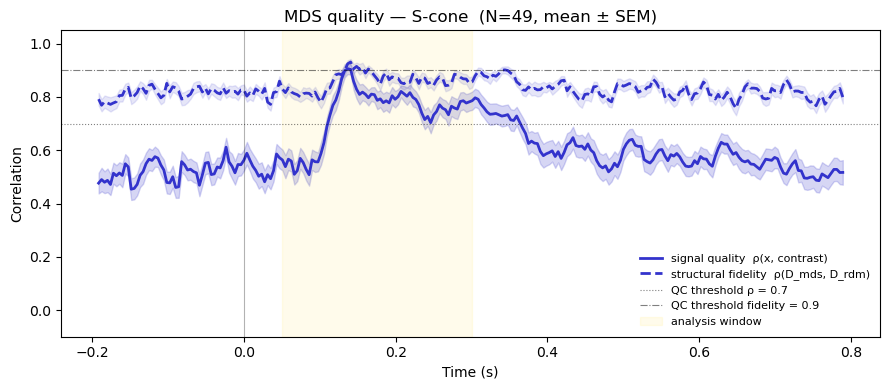

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/S-cone/S-cone_mds_quality.png


In [18]:
# ── Cell 6: Group MDS quality plot (mean ± SEM) ───────────────────────────────
#
# Shows two curves over time:
#   rho      — signal quality  (how well MDS axis tracks contrast)
#   distcorr — structural fidelity  (how faithfully MDS preserves distances)
#
# Dashed lines mark the QC thresholds. The window where both curves are
# above threshold is where the MDS embedding is reliable enough to fit NR.
#
# Uses PATHWAY set in Cell 3.

R, DC, t_ref = [], [], None

for subject in SUBJECTS:
    f = mds_dir / f'sub-{subject}_mds_timecourses.npz'
    if not f.exists():
        continue
    with np.load(f, allow_pickle=False) as d:
        t  = d['time'].astype(float)
        R.append(d['rho'].astype(float))
        DC.append(d['distcorr'].astype(float))
    if t_ref is None:
        t_ref = t

if not R:
    print('No MDS files found — run Cell 5 first.')
else:
    R  = np.vstack(R)
    DC = np.vstack(DC)
    n  = R.shape[0]

    r_m  = np.nanmean(R,  0);  r_s  = np.nanstd(R,  0, ddof=1) / np.sqrt(n)
    dc_m = np.nanmean(DC, 0);  dc_s = np.nanstd(DC, 0, ddof=1) / np.sqrt(n)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_title(f'MDS quality — {PATHWAY}  (N={n}, mean ± SEM)')

    ax.plot(t_ref, r_m,  color=color, lw=2, label='signal quality  ρ(x, contrast)')
    ax.fill_between(t_ref, r_m - r_s,  r_m + r_s,  color=color, alpha=0.2)

    ax.plot(t_ref, dc_m, color=color, lw=2, ls='--', label='structural fidelity  ρ(D_mds, D_rdm)')
    ax.fill_between(t_ref, dc_m - dc_s, dc_m + dc_s, color=color, alpha=0.12)

    ax.axhline(QC_RHO,   color='k', lw=0.8, ls=':', alpha=0.5, label=f'QC threshold ρ = {QC_RHO}')
    ax.axhline(QC_DCORR, color='k', lw=0.8, ls='-.', alpha=0.5, label=f'QC threshold fidelity = {QC_DCORR}')
    ax.axvline(0, color='k', lw=0.8, alpha=0.3)
    ax.axvspan(*TIME_RANGE, color='gold', alpha=0.08, label='analysis window')

    ax.set_xlabel('Time (s)'); ax.set_ylabel('Correlation')
    ax.set_ylim(-0.1, 1.05)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()

    out = plots_dir / f'{PATHWAY}_mds_quality.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out}')